### K-fold 교차 검증
- 훈련 세트를 k 개의 폴드로 나눈다
- 모든 폴드를 검증과 훈련에 사용할 수 있으므로 검증 점수가 안정적이다.
- 기존의 방식대로 데이터를 [훈련 | 검증 | 테스트] 로 정적으로 구분하면 모델이 이 구분된 데이터에만 최적화될 수 있음.
- [훈련/검증 | 테스트] 로 나눈뒤 훈련/검증 세트를 가지고 K-fold 교차 검증을 진행한다.

455 114
364 91
0.9711111111111113
[0.9333333333333333, 0.9777777777777777, 0.9555555555555556, 0.9777777777777777, 0.9555555555555556, 1.0, 0.9555555555555556, 1.0, 1.0, 0.9555555555555556]


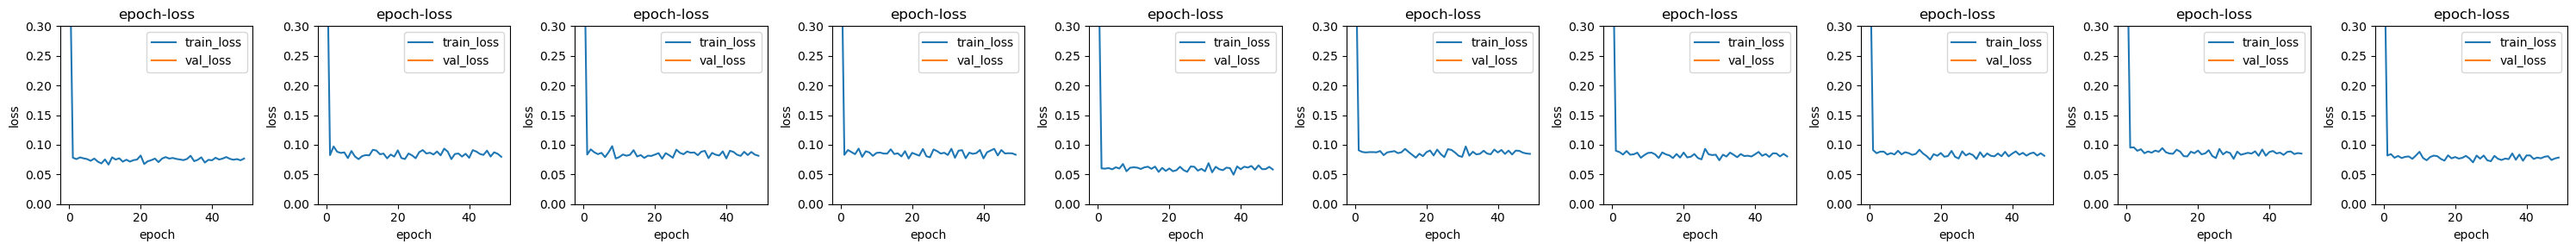

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

class SingleLayer:
    def __init__(self, learning_rate=0.1, l1=0, l2=0):
        self.w = None
        self.b = None
        self.losses = []
        self.val_losses = []
        self.w_history = []
        self.lr = learning_rate

        self.l1 = l1 # L1 추가
        self.l2 = l2 # L2 추가

    def forpass(self, x):
        z = np.sum(x * self.w) + self.b
        return z
    
    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad
    
    def activation(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a
    
    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        self.w = np.ones(x.shape[1])
        self.b = 0
        self.w_history.append(self.w.copy())
        np.random.seed(42)
        for i in range(epochs):
            loss = 0
            indexes = np.random.permutation(np.arange(len(x)))
            for i in indexes:
                z = self.forpass(x[i])
                a = self.activation(z)
                err = -(y[i] - a)
                w_grad, b_grad = self.backprop(x[i], err)

                w_grad += self.l1*np.sign(self.w) + self.l2 * self.w # L1, L2 규제 항 추가

                self.w -= self.lr * w_grad
                self.b -= b_grad
                self.w_history.append(self.w.copy())
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += -(y[i]*np.log(a) + (1-y[i])*np.log(1-a))
            self.losses.append(loss/len(y))
            self.update_val_loss(x_val, y_val)

    
    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]
        return np.array(z) > 0
    
    def score(self, x, y):
        return np.mean(self.predict(x) == y)

    def reg_loss(self):
        return self.l1 * np.sum(np.abs(self.w)) + self.l2 / 2*np.sum(self.w**2) # L1, L2 계산

    def update_val_loss(self, x_val, y_val):
        if x_val is None:
            return
        val_loss = 0
        for i in range(len(x_val)):
            z = self.forpass(x_val[i])
            a = self.activation(z)
            a = np.clip(a, 1e-10, 1-1e-10)
            val_loss += -(y_val[i]*np.log(a) + (1-y_val[i])*np.log(1-a))
        self.val_losses.append(val_loss/len(y_val))
    

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))

x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(len(x_train), len(x_val))


# 교차 검증 구현
validation_scores = []

k = 10
bins = len(x_train_all) // k

figsize = 3
fig, axes = plt.subplots(1, k, figsize=(figsize*k, figsize))

"""
k = 10, len(x_train_all) == 50

bins = 50 // 10 = 5

    0   1   2   3   4   5   6   7   8   9   10  11  ...
    | start = 0*bins    | end = (i+1)*bins
    | [start:end](검증) |
< range(0, start)       > range(end, len(x_train_all) (훈련에 쓸 데이터(0 <= i < start || end <= i < length))
    

"""

for i in range(k):
    start = i * bins
    end = (i+1)*bins
    val_fold = x_train_all[start:end]
    val_target = y_train_all[start:end]

    train_index = list(range(0, start)) + list(range(end, len(x_train_all)))
    train_fold = x_train_all[train_index]
    train_target = y_train_all[train_index]

    train_mean = np.mean(train_fold, axis=0)
    train_std = np.std(train_fold, axis=0)
    train_fold_scaled = (train_fold - train_mean) / train_std

    val_fold_scaled = (val_fold - train_mean) / train_std

    layer = SingleLayer(l2=0.01)
    layer.fit(train_fold_scaled, train_target, epochs=50)
    score = layer.score(val_fold_scaled, val_target)
    validation_scores.append(score)

    axes[i].set_title("epoch-loss")
    axes[i].set_ylim(0, 0.3)
    axes[i].plot(layer.losses)
    axes[i].plot(layer.val_losses)
    axes[i].set_ylabel('loss')
    axes[i].set_xlabel('epoch')
    axes[i].legend(['train_loss', 'val_loss'])

print(np.mean(validation_scores))
print(validation_scores)

plt.tight_layout()
plt.show()

In [ ]:
# Sci-kit learn 을 활용한 K-fold 교차 검증
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

import numpy as np

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))

sgd = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.001, random_state=42)
pipe = make_pipeline(StandardScaler(), sgd)
# StandardScaler(): 데이터를 평균 0 표준편차 1이 되도록 표준화 함.
# make_pipeline: 데이터가 들어오면 StandardScaler의 fit과 transform을 거친 후 sgd에 전달
# 교차 검증 시 각 폴드마다 훈련용 폴드의 통계량으로만 스케일링을 하고 검증용 폴드에 적용하게끔 자동 관리

scores = cross_validate(pipe, x_train_all, y_train_all, cv=10, return_train_score=True)
# k-fold 교차 검증 수행
# cv: k
# return_train_score: 검증 점수외에도 훈련 점수 반환(과적합 여부 판단)
print(np.mean(scores['test_score']))
print(np.mean(scores['train_score']))


455 114
0.9694202898550724
0.9875478561631581


### 벡터화된 연산
- numpy 및 다른 머신러닝, 딥러닝 패키지들은 다차원 배열의 계산을 빠르게 수행
- 백터화(vecotrization)된 연산으로 알고리즘의 성능을 올릴 수 있음
- 행렬곱(1차원에서 내적, 스칼라 곱)을 도입하면 단일층 신경망의 연산을 간결하게 표현할 수 있음

#### 샘플이 1개일 때(특성 n개)
$$
\begin{align*}
X &= \begin{bmatrix} x_1 & x_2 & \cdots & x_n\end{bmatrix} \\
W &= \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_n\end{bmatrix} \\

\\
z &= w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b \\ 
& = X W + b

\end{align*}
$$  


```python
z = np.dot(x, self.w) + self.b
```

#### 샘플이 m개일 때(특성 n개)
$$
\begin{align*}
X &= 
\begin{bmatrix} x_{1 1} & x_{1 2} & \cdots & x_{1 n} \\ x_{2 1} & x_{2 2} & \cdots & x_{2 n} \\ \vdots & \vdots & \ddots & \vdots & \\ x_{m 1} & x_{m 2} & \cdots & x_{m n} \end{bmatrix} \\
W &= \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_n\end{bmatrix} \\

\\
Z &= XW + b \\ 
&= \begin{bmatrix} \sum_{i=1}^{n} x_{1 i} w_i + b\\ \sum_{i=1}^{n} x_{2 i} w_i + b\\ \vdots \\ \sum_{i=1}^{n} x_{m i} w_i + b\end{bmatrix} \\
&= \begin{bmatrix} z_1 \\ z_2 \\ \vdots \\ z_m\end{bmatrix}
\end{align*}
$$  


```python
z = np.dot(x, self.w) + self.b # 스칼라 self.b 가 브로드캐스팅 됨. 반복문이 필요없어 속도/효율에 장점
```




455 114
364 91
0.5319405868856418


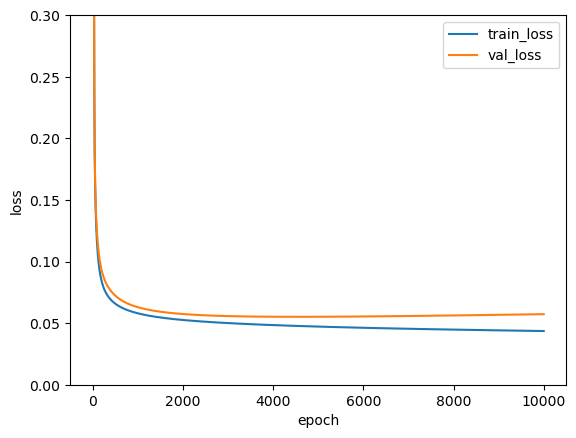

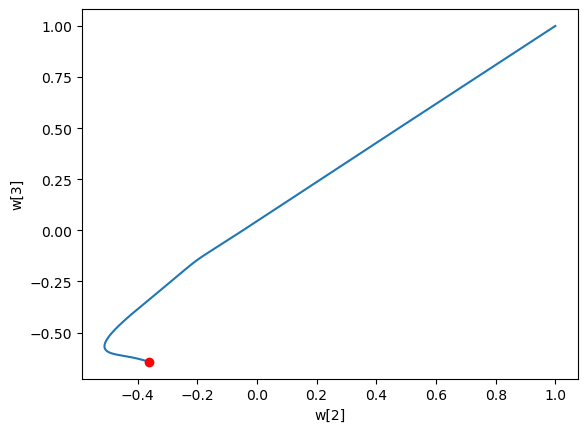

In [31]:
# 행렬 연산을 적용

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

class SingleLayer:
    def __init__(self, learning_rate=0.1, l1=0, l2=0):
        self.w = None
        self.b = None
        self.losses = []
        self.val_losses = []
        self.w_history = []
        self.lr = learning_rate

        self.l1 = l1 # L1 추가
        self.l2 = l2 # L2 추가

    def forpass(self, x): # forpass 함수는 이제 샘플 1개의 특성의 배열이 아닌 행렬 전체를 받음.
        # z = np.sum(x * self.w) + self.b
        z = np.dot(x, self.w) + self.b # 기존의 비효율적인 * 및 sum 연산 대체
        # x는 m*n, w는 n*1 이므로 z는 m*1 행렬 
        return z
    
    def backprop(self, x, err): # backprop 함수는 이제 샘플 1개의 특성의 배열이 아닌 행렬 전체를 받음. err도 각 샘플별 오차 리스트를 받음.
        # w_grad = x * err
        # b_grad = 1 * err
        m = len(x)
        w_grad = np.dot(x.T, err) / m # x는 m(샘플) * n(특성) 행렬, err는 m(샘플 별 오차) * 1 이므로 x를 전치하여 차원 맞춤.
        b_grad = np.sum(err) / m
        return w_grad, b_grad
    
    def activation(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a
    
    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        y = y.reshape(-1, 1) # 열 벡터로 바꿈(-1은 자동)
        y_val = y_val.reshape(-1, 1)
        m = len(x)

        self.w = np.ones((x.shape[1], 1))
        self.b = 0
        self.w_history.append(self.w.copy())

        for i in range(epochs):

            z = self.forpass(x)
            a = self.activation(z)
            err = -(y - a) # 오차 계산(샘플 별, y, z 모두 n*1 행렬 -> err는 n*1행렬 )

            w_grad, b_grad = self.backprop(x, err)
            w_grad += (self.l1 * np.sign(self.w) + self.l2 * self.w) / m

            self.w -= self.lr * w_grad
            self.b -= self.lr * b_grad

            self.w_history.append(self.w.copy())

            a = np.clip(a, 1e-10, 1-1e-10)

            loss = np.sum(-(y*np.log(a) + (1-y)*np.log(1-a)))

            self.losses.append((loss + self.reg_loss()) / m)
            self.update_val_loss(x_val, y_val)

    
    def predict(self, x):
        z = self.forpass(x)
        return z > 0
    
    def score(self, x, y):
        return np.mean(self.predict(x) == y)

    def reg_loss(self):
        return self.l1 * np.sum(np.abs(self.w)) + self.l2 / 2*np.sum(self.w**2) # L1, L2 계산

    def update_val_loss(self, x_val, y_val):

        z = self.forpass(x_val)
        a = self.activation(z)
        a = np.clip(a, 1e-10, 1-1e-10)

        val_loss = np.sum(-(y_val*np.log(a) + (1-y_val)*np.log(1-a)))
        self.val_losses.append((val_loss + self.reg_loss()) / len(y_val))

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))

x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(len(x_train), len(x_val))

scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_val_scaled = scaler.transform(x_val)

single_layer = SingleLayer(l2=0.01)
single_layer.fit(x_train_scaled, y_train, x_val=x_val_scaled, y_val = y_val, epochs=10000)

print(single_layer.score(x_val_scaled, y_val))

plt.ylim(0, 0.3)
plt.plot(single_layer.losses)
plt.plot(single_layer.val_losses)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

w2 = []
w3 = []
for w in single_layer.w_history:
    w2.append(w[2])
    w3.append(w[3])

plt.plot(w2, w3)
plt.plot(w2[-1], w3[-1], 'ro')
plt.xlabel('w[2]')
plt.ylabel('w[3]')

plt.show()